## Analyse complète des métriques d'évaluation

Objectif: vérifier toutes les métriques produites par `evaluate_ragas.py` dans le dernier `ragas_details_*.csv`.

Blocs suivis:
- **RAGAS core**: `answer_relevancy`, `faithfulness`, `context_precision`, `context_recall`
- **Retrieval**: `retrieval_precision_at_k`, `retrieval_recall_at_k`, `retrieval_mrr`, `retrieval_ndcg_at_k`, `retrieval_keyword_coverage`, `retrieval_keywords_count`
- **Opérationnel**: latences (`latency_*`), tokens (`input/output/total_tokens`) et coût (`estimated_cost_usd`)


In [25]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

csv_candidates = sorted(Path('outputs/evaluations').glob('ragas_details_*.csv'))
if not csv_candidates:
    raise FileNotFoundError("Aucun fichier ragas_details_*.csv trouvé dans outputs/evaluations")

csv_path = csv_candidates[-1]
df = pd.read_csv(csv_path)
print(f"CSV chargé: {csv_path}")
print(f"Shape: {df.shape}")

metric_groups = {
    'ragas_core': ['answer_relevancy', 'faithfulness', 'context_precision', 'context_recall'],
    'retrieval_quality': ['retrieval_precision_at_k', 'retrieval_recall_at_k', 'retrieval_mrr', 'retrieval_ndcg_at_k', 'retrieval_keyword_coverage'],
    'retrieval_volume': ['retrieval_keywords_count'],
    'latency': ['latency_retrieval_s', 'latency_generation_s', 'latency_total_s'],
    'tokens_cost': ['input_tokens', 'output_tokens', 'total_tokens', 'estimated_cost_usd'],
}

available_metrics = {k: [c for c in cols if c in df.columns] for k, cols in metric_groups.items()}
all_metrics = []
for cols in available_metrics.values():
    all_metrics.extend(cols)
all_metrics = list(dict.fromkeys(all_metrics))

if not all_metrics:
    raise ValueError("Aucune métrique trouvée dans le CSV chargé")

presence_rows = []
for group_name, expected in metric_groups.items():
    found = available_metrics[group_name]
    missing = [m for m in expected if m not in found]
    presence_rows.append({
        'groupe': group_name,
        'nb_attendues': len(expected),
        'nb_disponibles': len(found),
        'disponibles': ', '.join(found) if found else '-',
        'manquantes': ', '.join(missing) if missing else '-',
    })

display(pd.DataFrame(presence_rows))
print('Colonnes du CSV:', list(df.columns))
df.head()


CSV chargé: outputs/evaluations/ragas_details_20260314_142802.csv
Shape: (11, 24)


,groupe,nb_attendues,nb_disponibles,disponibles,manquantes
0,ragas_core,4,4,"answer_relevancy, faithfulness, context_precis...",-
1,retrieval_quality,5,5,"retrieval_precision_at_k, retrieval_recall_at_...",-
2,retrieval_volume,1,1,retrieval_keywords_count,-
3,latency,3,3,"latency_retrieval_s, latency_generation_s, lat...",-
4,tokens_cost,4,4,"input_tokens, output_tokens, total_tokens, est...",-


Colonnes du CSV: ['sample_index', 'id', 'category', 'user_input', 'retrieved_contexts', 'response', 'reference', 'answer_relevancy', 'faithfulness', 'context_precision', 'context_recall', 'latency_retrieval_s', 'latency_generation_s', 'latency_total_s', 'input_tokens', 'output_tokens', 'total_tokens', 'estimated_cost_usd', 'retrieval_precision_at_k', 'retrieval_recall_at_k', 'retrieval_mrr', 'retrieval_ndcg_at_k', 'retrieval_keyword_coverage', 'retrieval_keywords_count']


,sample_index,id,category,user_input,retrieved_contexts,response,reference,answer_relevancy,faithfulness,context_precision,...,input_tokens,output_tokens,total_tokens,estimated_cost_usd,retrieval_precision_at_k,retrieval_recall_at_k,retrieval_mrr,retrieval_ndcg_at_k,retrieval_keyword_coverage,retrieval_keywords_count
0,0,q1,simple,Quel est le nom complet de l'equipe codee OKC ?,"[""Code Nom complet de l'équipe 0 ATL Atlanta H...",Oklahoma City Thunder,OKC correspond a Oklahoma City Thunder.,0.771397,1.0,0.833333,...,1029,5,1034,NaN,0.6,1.0,1.0,0.958272,1.0,2
1,1,q2,simple,"Selon le tableau des equipes, combien de point...","[""4 Code Nom complet de l'équipe Nombre de jou...","Selon le contexte fourni, OKC a un total de 98...",OKC totalise 9880 points.,0.841015,1.0,1.000000,...,841,19,860,NaN,0.6,1.0,1.0,1.000000,1.0,2
2,2,q3,complex,"Parmi MIA, OKC, LAC et BKN, quelle equipe a le...","[""4 Code Nom complet de l'équipe Nombre de jou...",OKC Oklahoma City Thunder avec 9880 points tot...,"Parmi ces quatre equipes, OKC est premier avec...",0.755069,1.0,1.000000,...,696,16,712,NaN,0.6,1.0,1.0,1.000000,1.0,5
3,3,q4,complex,Quelle est la difference de points totaux entr...,"[""4 Code Nom complet de l'équipe Nombre de jou...",La différence de points totaux entre OKC (9880...,La difference est de 52 points.,0.985481,1.0,1.000000,...,1062,32,1094,NaN,0.6,0.8,1.0,0.979909,0.8,5
4,4,q5,simple,Combien de joueurs compte l'equipe Brooklyn Ne...,"[""Code Nom complet de l'équipe 0 ATL Atlanta H...",L'équipe Brooklyn Nets (BKN) compte 20 joueurs.,BKN compte 20 joueurs.,0.938663,1.0,0.500000,...,688,15,703,NaN,0.6,1.0,1.0,1.000000,1.0,3


### Commentaire du Graphique 1: Diagnostic qualité global
Ce graphique vérifie la **complétude** des métriques (taux de `NaN`) et la cohérence statistique minimale (distribution, min/max, moyenne).

Ce que ça vérifie:
- que chaque métrique est réellement calculée,
- qu'on ne base pas l'analyse sur des colonnes vides,
- qu'il n'y a pas de dérive évidente (valeurs hors plage attendue).

Pertinence pour l'efficacité recherchée:
- sans complétude, les décisions d'optimisation RAG sont peu fiables,
- une métrique très manquante peut masquer un problème d'API, de dépendance ou de pipeline.

Commentaire sur le score:
- cible recommandée: **< 5% de NaN** sur les métriques core,
- entre 5% et 20%: lecture prudente,
- au-delà: corriger la collecte avant d'interpréter les scores.


,na_ratio,non_null_count,dtype
answer_relevancy,0.0,11,float64
context_precision,0.0,11,float64
context_recall,0.0,11,float64
estimated_cost_usd,1.0,0,float64
faithfulness,0.0,11,float64
input_tokens,0.0,11,int64
latency_generation_s,0.0,11,float64
latency_retrieval_s,0.0,11,float64
latency_total_s,0.0,11,float64
output_tokens,0.0,11,int64


,count,mean,std,min,25%,50%,75%,max
answer_relevancy,11.0,0.760194,0.281536,0.000000,0.696868,0.841015,0.936482,0.985481
faithfulness,11.0,0.863636,0.323335,0.000000,1.000000,1.000000,1.000000,1.000000
context_precision,11.0,0.730303,0.369821,0.000000,0.500000,1.000000,1.000000,1.000000
context_recall,11.0,0.909091,0.301511,0.000000,1.000000,1.000000,1.000000,1.000000
retrieval_precision_at_k,11.0,0.472727,0.184883,0.200000,0.300000,0.600000,0.600000,0.600000
retrieval_recall_at_k,11.0,0.904545,0.190335,0.400000,0.900000,1.000000,1.000000,1.000000
retrieval_mrr,11.0,0.909091,0.202260,0.500000,1.000000,1.000000,1.000000,1.000000
retrieval_ndcg_at_k,11.0,0.889089,0.170950,0.513892,0.848488,0.979909,1.000000,1.000000
retrieval_keyword_coverage,11.0,0.904545,0.190335,0.400000,0.900000,1.000000,1.000000,1.000000
retrieval_keywords_count,11.0,3.454545,1.213560,2.000000,2.500000,3.000000,4.500000,5.000000


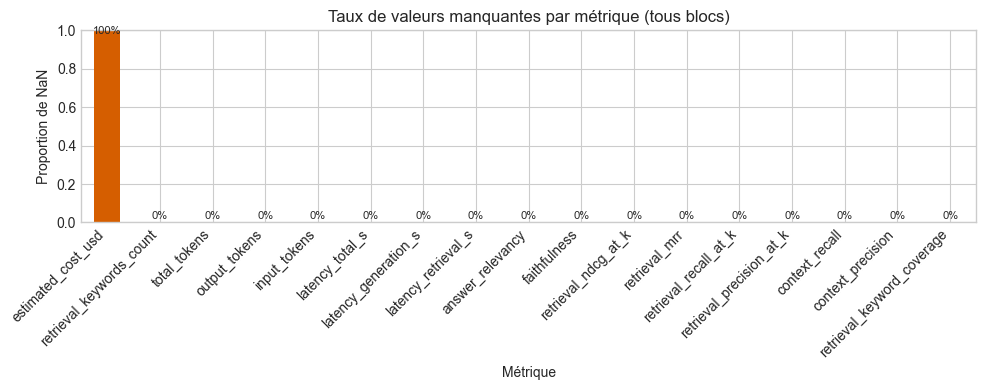

In [26]:
# 1) Diagnostic qualité global: valeurs manquantes + stats descriptives
na_ratio = df[all_metrics].isna().mean().sort_values(ascending=False)
diag = pd.DataFrame({
    'na_ratio': na_ratio,
    'non_null_count': df[all_metrics].notna().sum(),
    'dtype': df[all_metrics].dtypes.astype(str),
})
display(diag)
display(df[all_metrics].describe().T)

ax = na_ratio.plot(kind='bar', color='#D55E00', figsize=(10, 4), ylim=(0, 1))
ax.set_title('Taux de valeurs manquantes par métrique (tous blocs)')
ax.set_ylabel('Proportion de NaN')
ax.set_xlabel('Métrique')
for i, v in enumerate(na_ratio.values):
    ax.text(i, min(v + 0.02, 0.98), f"{v:.0%}", ha='center', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Commentaire du Graphique 2: RAGAS core
Ce graphique évalue la qualité centrale du système:
- `answer_relevancy` (réponse pertinente vis-à-vis de la question),
- `faithfulness` (réponse fidèle au contexte),
- `context_precision` (qualité des contextes récupérés),
- `context_recall` (couverture du contexte utile par rapport à la référence).

Ce que ça vérifie:
- la qualité de génération et la robustesse factuelle,
- l'alignement entre retriever et générateur.

Pertinence pour l'efficacité recherchée:
- ces métriques mesurent directement la capacité du RAG à produire des réponses utiles et fiables.

Commentaire sur le score:
- repère pratique: **>= 0.85 excellent**, **0.70-0.85 correct**, **< 0.70 à améliorer**,
- sur ton run récent: `answer_relevancy ~0.76`, `faithfulness ~0.84`, `context_precision ~0.73`, `context_recall ~0.91`.
- lecture: système globalement fiable, mais encore du bruit côté retrieval/précision.


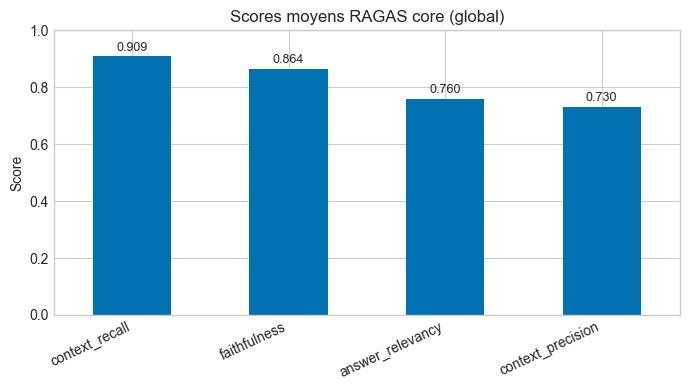

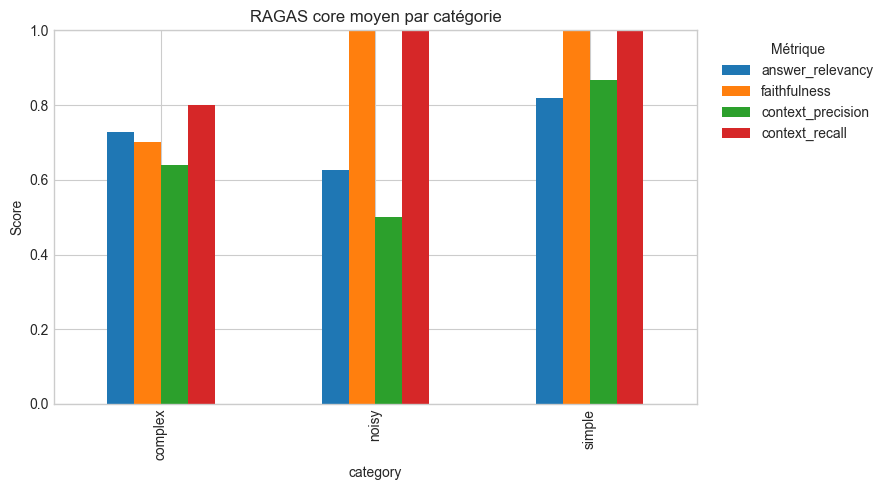

,answer_relevancy,faithfulness,context_precision,context_recall
category,,,,
complex,0.726893,0.7,0.640000,0.8
noisy,0.626774,1.0,0.500000,1.0
simple,0.820179,1.0,0.866667,1.0


In [27]:
# 2) Vue RAGAS core (global + par catégorie)
core_metrics = available_metrics['ragas_core']
if not core_metrics:
    print("Aucune métrique RAGAS core trouvée dans ce CSV.")
else:
    mean_scores = df[core_metrics].mean().sort_values(ascending=False)
    ax = mean_scores.plot(kind='bar', color='#0072B2', figsize=(7, 4), ylim=(0, 1))
    ax.set_title('Scores moyens RAGAS core (global)')
    ax.set_ylabel('Score')
    for i, v in enumerate(mean_scores.values):
        ax.text(i, min(v + 0.02, 0.98), f"{v:.3f}", ha='center', fontsize=9)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()

    if 'category' in df.columns:
        by_cat = df.groupby('category', dropna=False)[core_metrics].mean().sort_index()
        ax = by_cat.plot(kind='bar', figsize=(9, 5), ylim=(0, 1))
        ax.set_title('RAGAS core moyen par catégorie')
        ax.set_ylabel('Score')
        ax.legend(title='Métrique', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        display(by_cat)


### Commentaire du Graphique 3: Retrieval (qualité + volume)
Ce bloc vérifie:
- la qualité du ranking (`precision@k`, `recall@k`, `MRR`, `nDCG`),
- la couverture de mots-clés (`retrieval_keyword_coverage`),
- le volume d'indices suivis (`retrieval_keywords_count`).

Ce que ça vérifie:
- si les chunks utiles arrivent bien en tête,
- si la recherche couvre la demande sans trop de bruit.

Pertinence pour l'efficacité recherchée:
- un retrieval faible plafonne la génération, même avec un bon LLM.

Commentaire sur le score:
- un `recall@k` élevé avec `precision@k` moyenne indique souvent une récupération large mais bruitée,
- dans ce cas, prioriser: chunking, filtrage, re-ranking, ou reformulation de requête.


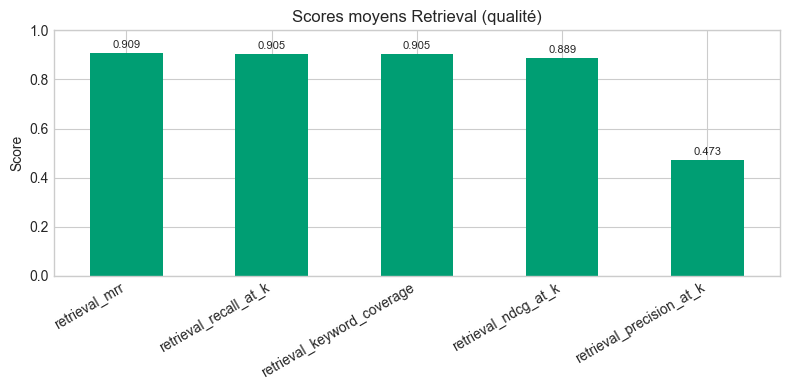

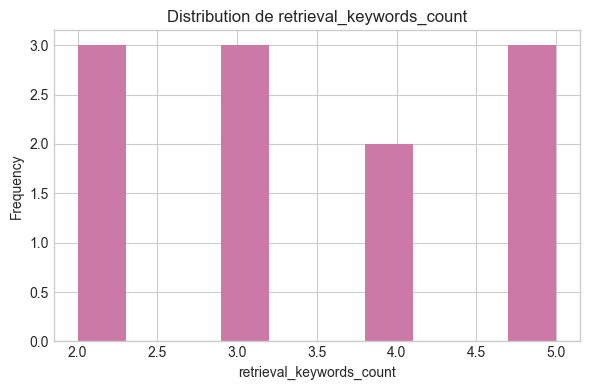

,count,mean,std,min,25%,50%,75%,max
retrieval_precision_at_k,11.0,0.472727,0.184883,0.200000,0.300000,0.600000,0.6,0.6
retrieval_recall_at_k,11.0,0.904545,0.190335,0.400000,0.900000,1.000000,1.0,1.0
retrieval_mrr,11.0,0.909091,0.202260,0.500000,1.000000,1.000000,1.0,1.0
retrieval_ndcg_at_k,11.0,0.889089,0.170950,0.513892,0.848488,0.979909,1.0,1.0
retrieval_keyword_coverage,11.0,0.904545,0.190335,0.400000,0.900000,1.000000,1.0,1.0
retrieval_keywords_count,11.0,3.454545,1.213560,2.000000,2.500000,3.000000,4.5,5.0


In [28]:
# 3) Vue retrieval (qualité + volume)
retrieval_quality = available_metrics['retrieval_quality']
retrieval_volume = available_metrics['retrieval_volume']

if retrieval_quality:
    quality_mean = df[retrieval_quality].mean().sort_values(ascending=False)
    ax = quality_mean.plot(kind='bar', color='#009E73', figsize=(8, 4), ylim=(0, 1))
    ax.set_title('Scores moyens Retrieval (qualité)')
    ax.set_ylabel('Score')
    for i, v in enumerate(quality_mean.values):
        ax.text(i, min(v + 0.02, 0.98), f"{v:.3f}", ha='center', fontsize=8)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

if retrieval_volume:
    vol_col = retrieval_volume[0]
    ax = df[vol_col].plot(kind='hist', bins=10, color='#CC79A7', figsize=(6, 4))
    ax.set_title(f"Distribution de {vol_col}")
    ax.set_xlabel(vol_col)
    plt.tight_layout()
    plt.show()

retrieval_cols = retrieval_quality + retrieval_volume
if retrieval_cols:
    display(df[retrieval_cols].describe().T)
else:
    print("Aucune métrique retrieval détectée.")


### Commentaire du Graphique 4: Opérationnel (latence, tokens, coût)
Ce bloc vérifie l'efficacité **technique et économique**:
- latence de retrieval/génération/total,
- volume de tokens,
- coût estimé (si les prix tokens sont fournis).

Ce que ça vérifie:
- la soutenabilité en usage réel (temps de réponse, budget API),
- l'impact des choix méthodologiques sur la performance runtime.

Pertinence pour l'efficacité recherchée:
- un pipeline précis mais lent/coûteux n'est pas viable en production.

Commentaire sur le score:
- surveiller la variance (p95/p99), pas seulement la moyenne,
- `estimated_cost_usd` vide est normal si aucun tarif n'est passé au script.


,count,mean,std,min,25%,50%,75%,max
latency_retrieval_s,11.0,0.567285,0.313682,0.232744,0.363984,0.507530,0.674492,1.351722
latency_generation_s,11.0,0.354384,0.083179,0.220369,0.321250,0.352194,0.408173,0.494917
latency_total_s,11.0,0.922041,0.327766,0.641672,0.712749,0.821606,0.961831,1.733798
input_tokens,11.0,848.181818,161.494779,595.000000,692.000000,864.000000,969.000000,1062.000000
output_tokens,11.0,18.727273,12.962183,5.000000,8.500000,16.000000,25.500000,46.000000
total_tokens,11.0,866.909091,158.071158,641.000000,707.500000,895.000000,983.000000,1094.000000
estimated_cost_usd,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


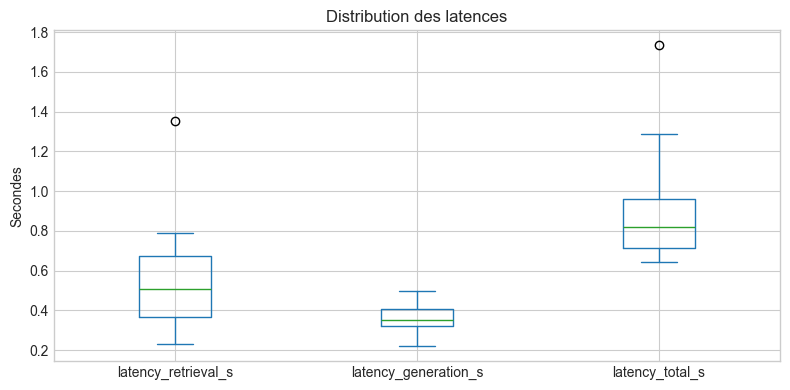

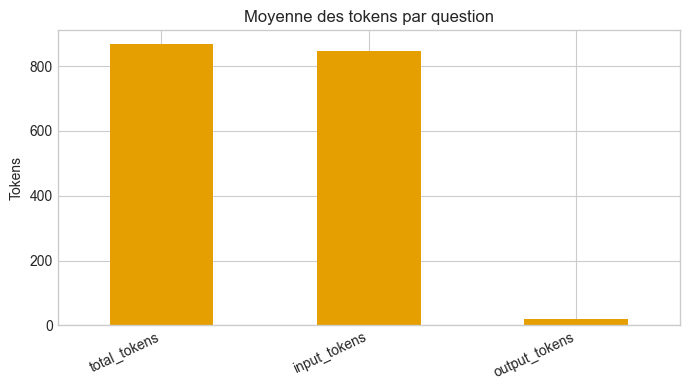

estimated_cost_usd: aucune valeur (prix tokens non fournis).


In [29]:
# 4) Vue opérationnelle (latence + tokens + coût)
latency_cols = available_metrics['latency']
token_cols = [c for c in available_metrics['tokens_cost'] if c != 'estimated_cost_usd']
cost_cols = [c for c in available_metrics['tokens_cost'] if c == 'estimated_cost_usd']

ops_cols = latency_cols + token_cols + cost_cols
if not ops_cols:
    print("Aucune métrique opérationnelle détectée.")
else:
    display(df[ops_cols].describe().T)

    if latency_cols:
        ax = df[latency_cols].plot(kind='box', figsize=(8, 4))
        ax.set_title('Distribution des latences')
        ax.set_ylabel('Secondes')
        plt.tight_layout()
        plt.show()

    if token_cols:
        mean_tokens = df[token_cols].mean().sort_values(ascending=False)
        ax = mean_tokens.plot(kind='bar', color='#E69F00', figsize=(7, 4))
        ax.set_title('Moyenne des tokens par question')
        ax.set_ylabel('Tokens')
        plt.xticks(rotation=25, ha='right')
        plt.tight_layout()
        plt.show()

    if cost_cols:
        cost_col = cost_cols[0]
        non_null_cost = df[cost_col].dropna()
        if non_null_cost.empty:
            print(f"{cost_col}: aucune valeur (prix tokens non fournis).")
        else:
            ax = non_null_cost.plot(kind='hist', bins=10, color='#56B4E9', figsize=(6, 4))
            ax.set_title('Distribution du coût estimé (USD)')
            ax.set_xlabel('USD')
            plt.tight_layout()
            plt.show()


### Commentaire du Graphique 5: Score agrégé par question
Ce graphique vérifie la performance **au niveau question**, pas seulement en moyenne globale.

Ce que ça vérifie:
- les points faibles précis (questions/catégories),
- les cas où retrieval ou génération se dégradent localement.

Pertinence pour l'efficacité recherchée:
- c'est la vue la plus actionnable pour prioriser les corrections.

Commentaire sur le score:
- travailler d'abord les questions les plus faibles,
- vérifier leurs contextes récupérés et la formulation de la question,
- puis mesurer l'impact des corrections sur ce classement.


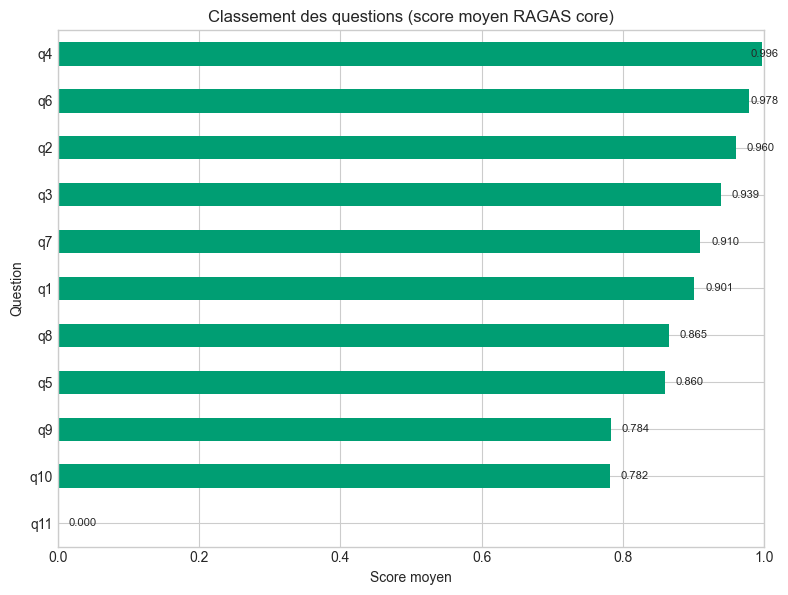

,id,category,score_moyen_ragas_core,retrieval_precision_at_k,retrieval_recall_at_k,retrieval_mrr,retrieval_ndcg_at_k,retrieval_keyword_coverage,latency_total_s,total_tokens,estimated_cost_usd
3,q4,complex,0.996370,0.6,0.80,1.0,0.979909,0.80,0.660321,1094,NaN
5,q6,simple,0.977788,0.2,1.00,1.0,1.000000,1.00,1.733798,971,NaN
1,q2,simple,0.960254,0.6,1.00,1.0,1.000000,1.00,1.041612,860,NaN
2,q3,complex,0.938767,0.6,1.00,1.0,1.000000,1.00,0.641672,712,NaN
6,q7,simple,0.909667,0.6,1.00,1.0,0.907575,1.00,0.821606,948,NaN
0,q1,simple,0.901182,0.6,1.00,1.0,0.958272,1.00,0.795562,1034,NaN
7,q8,complex,0.864904,0.2,0.75,1.0,1.000000,0.75,0.855221,895,NaN
4,q5,simple,0.859666,0.6,1.00,1.0,1.000000,1.00,0.678219,703,NaN
8,q9,complex,0.783575,0.4,1.00,0.5,0.513892,1.00,1.285109,641,NaN
9,q10,noisy,0.781693,0.6,1.00,1.0,0.789401,1.00,0.747279,683,NaN


In [30]:
# 5) Score agrégé par question + tableau consolidé
score_col = 'score_moyen_ragas_core'
rank_df = df.copy()
core_metrics = available_metrics['ragas_core']
if core_metrics:
    rank_df[score_col] = rank_df[core_metrics].mean(axis=1, skipna=True)
else:
    rank_df[score_col] = pd.NA

label_col = rank_df['id'].astype(str) if 'id' in rank_df.columns else rank_df.index.astype(str)
plot_df = rank_df[[score_col]].copy()
plot_df['label'] = label_col
plot_df = plot_df.sort_values(score_col, ascending=True, na_position='first')

if core_metrics:
    ax = plot_df.plot(kind='barh', x='label', y=score_col, legend=False, figsize=(8, max(3, 0.55 * len(plot_df))), xlim=(0, 1), color='#009E73')
    ax.set_title('Classement des questions (score moyen RAGAS core)')
    ax.set_xlabel('Score moyen')
    ax.set_ylabel('Question')
    for i, v in enumerate(plot_df[score_col].values):
        if pd.notna(v):
            ax.text(min(v + 0.015, 0.98), i, f"{v:.3f}", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

display_cols = [c for c in ['id', 'category', score_col] if c in rank_df.columns]
display_cols += [c for c in available_metrics['retrieval_quality'] if c in rank_df.columns]
display_cols += [c for c in ['latency_total_s', 'total_tokens', 'estimated_cost_usd'] if c in rank_df.columns]
display(rank_df[display_cols].sort_values(score_col, ascending=False, na_position='last'))


## Conclusion d'analyse (lecture recommandée)
Interpréter les résultats dans cet ordre:
1. **Complétude** des métriques (Graphique 1),
2. **Qualité RAGAS core** (Graphique 2),
3. **Diagnostic retrieval** (Graphique 3),
4. **Contraintes opérationnelles** (Graphique 4),
5. **Priorisation par question** (Graphique 5).

Cette séquence permet d'aligner la démarche avec l'efficacité recherchée: qualité de réponse, fiabilité factuelle, robustesse retrieval, puis viabilité runtime/coût.
